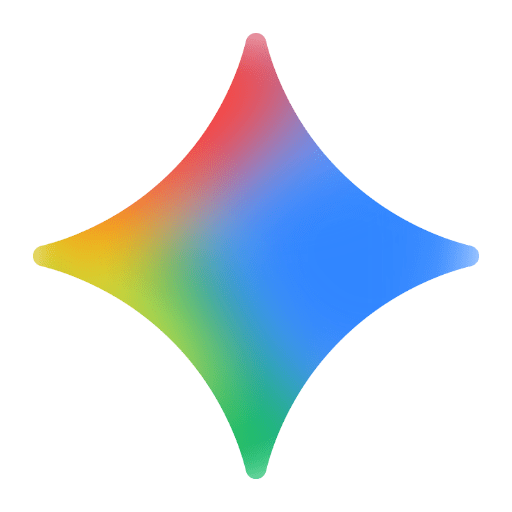

# Chapter 9: Software Development Agents

**Book:** *Agents* by Imran Ahmad (Packt, 2026)
**Author:** Imran Ahmad
**Chapter pages:** 235–279

Powered by **Google Gemini Flash 2.5**

> *"The art of programming is the art of organizing and mastering complexity."* — Edsger Dijkstra

---

## Introduction

This notebook is the companion code for **Chapter 9** of *Agents* (Packt, 2026). The chapter explores how AI agents are reshaping the way software is built, tested, and improved. Software development has always been about managing complexity through abstraction — from assembly to high-level languages, from manual builds to automated pipelines, from ad-hoc testing to continuous integration. AI agents represent the next step in this progression, bringing **reasoning and adaptation** to the engineering process rather than operating on fixed rules and predefined workflows.

Unlike a static analyzer that flags violations after code is written, an agent can generate compliant code from the start. Unlike a CI pipeline that executes a predetermined sequence of checks, an agent can plan a verification strategy, interpret failures, and refine its approach based on feedback. Tools like **Cursor** and **Devin** demonstrate this capability by autonomously navigating codebases, planning multi-step changes, and executing them across files.

The chapter builds directly on the foundations laid in **Chapter 5** (cognitive architectures) and **Chapter 7** (tool-use frameworks), applying them to software engineering itself.

### Three Agent Classes

| Agent Class | Feedback Loop | Chapter Section | Book Pages |
|:---|:---|:---:|:---:|
| **Code-Generation** | generate → test → refine | §9.2 | 239–255 |
| **Compliance-Driven** | scan → evaluate → remediate | §9.3 | 255–265 |
| **Self-Improving** | execute → observe → learn → adapt | §9.4 | 265–278 |

### Ecosystem & Tooling Layers (Figure 9.1, p. 237)

The agent ecosystem is organized into four functional layers:
1. **Orchestration Frameworks** — LangGraph, LangChain, Workflow Engines: define stateful workflows, refinement loops, memory flow, and tool coordination
2. **Reasoning Cores** — LLMs with retrieval (RAG), tool definitions, and task decomposition capabilities
3. **Quality & Security Gates** — Static analysis, type checking, policy-as-code, compliance rules embedded in the execution loop
4. **Observability Platforms** — Tracing, metrics, dashboards, and feedback loops for reliability and improvement

### The Shift Toward Autonomy (pp. 237–239)

Key emerging trends include **Test-Driven Generation (TDG)** as the default mode, **repository-grounded reasoning** to combat hallucinations, **multi-agent specialization** (planner/coder/critic roles), **policy-aware coding** that shifts compliance left, and **hybrid deployment models** balancing hosted and on-premise LLMs.

### Adoption Maturity Curve (Figure 9.2, p. 239)

Teams typically progress through four stages: **Drafting** (low-risk code generation) → **Review + Tests** (test synthesis and quality gates in CI) → **Conditional Autonomy** (agents generate PRs, humans approve merges) → **Feedback-Driven** (self-improving agents that learn from operational data).

> **Note — Conditional Autonomy** (p. 238): The agent can independently execute the full development cycle (code generation, testing, refinement, and pull request creation) but requires explicit human approval before changes are merged into production branches. *The agent proposes; the developer disposes.*

---

All cells execute in **Simulation Mode** without an API key. Set `GOOGLE_API_KEY` in a `.env` file to switch to Live Mode.


### Figure 9.1 — Agent Ecosystem: Four Functional Layers (p. 237)

```
┌─────────────────────────────────────────────────────────────────────┐
│  1. Orchestration Frameworks                                        │
│     LangGraph  │  LangChain  │  Workflow Engines                    │
│     Define stateful workflows, refinement loops, tool coordination  │
├─────────────────────────────────────────────────────────────────────┤
│                              ▼                                      │
│  2. Reasoning Cores                                                 │
│     LLMs  │  RAG  │  Tool Definitions  │  Task Decomposition       │
│     LLMs with retrieval, planning, and task decomposition           │
├─────────────────────────────────────────────────────────────────────┤
│                              ▼                                      │
│  3. Quality & Security Gates                                        │
│     Static Analysis │ Type Checking │ Policy as Code │ Compliance   │
│     Embed validation and compliance checks into the execution loop  │
├─────────────────────────────────────────────────────────────────────┤
│                              ▼                                      │
│  4. Observability Platforms                                         │
│     Tracing  │  Metrics  │  Dashboards  │  Feedback Loops           │
│     Provide tracing, metrics, and feedback for reliability          │
└─────────────────────────────────────────────────────────────────────┘
```


In [ ]:
import os
os.environ["LLM_PROVIDER"] = "google"

# Cell 2: Install dependencies (run once)
# Ref: requirements.txt — pinned versions for reproducibility
!pip install -r requirements.txt -q

In [ ]:
# Cell 3: Imports and API key resolution
# Ref: src/utils.py — zero-hardcode key chain, ColorLog, @fail_gracefully

import os
import sys
import json
from datetime import datetime, timezone

# Ensure chapter09 package is importable from repo root
_repo_root = os.path.dirname(os.path.abspath(''))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

# --- Core Framework ---
from chapter09.utils import ColorLog, fail_gracefully, get_api_key, is_simulation_mode

# --- State Models (§9.2, §9.4) ---
from chapter09.state_models import (
    Task, AgentState, AdaptationType,
    ImprovementHypothesis, PlannerOutput, FeedbackRecord,
)

# --- Mock Layer (Simulation Mode) ---
from chapter09.mock_llm import MockLLM, MockTestRunner

# --- Agent Nodes (§9.2) ---
from chapter09.agent_nodes import build_workflow, extract_code_from_response

# --- Compliance Engine (§9.3) ---
from chapter09.compliance_engine import (
    PolicyEngine, ComplianceScanner, RemediationGenerator,
    AuditTrail, DataFlowAnalyzer,
)

# --- Self-Improving Agents (§9.4) ---
from chapter09.self_improving import (
    SensingLayer, CriticAgent, PlannerAgent,
    LearningLayer, HITLCheckpoint, run_self_improvement_loop,
)

# --- API Key Resolution ---
api_key = get_api_key()

if is_simulation_mode():
    llm = MockLLM()
else:
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
        api_key=api_key,
        temperature=0.2,
        request_timeout=30,
    )
    ColorLog.success("Live Mode: ChatGoogleGenerativeAI initialized.")

In [ ]:
# Cell 4: Environment verification
# Confirms all modules loaded and displays active mode.

ColorLog.header("ENVIRONMENT VERIFICATION")

import pydantic
ColorLog.info(f"Python: {sys.version.split()[0]}")
ColorLog.info(f"Pydantic: {pydantic.__version__}")

try:
    import langgraph
    ColorLog.info(f"LangGraph: {langgraph.__version__}")
except Exception:
    ColorLog.warning("LangGraph not available — workflow demos will use direct node calls.")

ColorLog.info(f"Mode: {'Simulation (MockLLM)' if is_simulation_mode() else 'Live (ChatGoogleGenerativeAI)'}")
ColorLog.info(f"LLM type: {type(llm).__name__}")
ColorLog.success("All modules loaded. Ready to proceed.")

---

## §9.2 — Code-Generation Agents (pp. 239–255)

Code-Generation agents transform natural language specifications into working, tested implementations using **Test-Driven Generation (TDG)** — a methodology that adapts traditional test-driven development (TDD) for autonomous systems (p. 239).

### Why TDG Matters (p. 239)

Standard LLM code generation is a one-shot process: prompt → generate → accept/reject. This is inherently unreliable because the model may generate syntactically valid code that fails at runtime, produce correct logic that violates project conventions, or hallucinate APIs that don't exist. TDG eliminates this uncertainty by establishing an **executable specification** (the test suite) before any code is written. The agent's output is not considered complete until it demonstrably satisfies every assertion.

### The Three-Phase TDG Workflow (Figure 9.3, p. 240)

1. **Red** (Tester Agent) — Analyze requirements, identify edge cases, generate a comprehensive test suite. Tests *must* fail initially, proving they are active and the feature doesn't yet exist.
2. **Green** (Developer Agent) — Write minimal code to make the test suite pass. Test output returns as structured feedback, forcing iteration until all assertions succeed.
3. **Refactor** — Optimize code quality: eliminate duplication, extract reusable functions, apply style conventions. The test suite runs after every change to ensure behavior remains consistent.

### Multi-Agent Orchestration (Figure 9.4, pp. 241–243)

The implementation uses **LangGraph** for explicit state graphs with built-in conditional branching, persistent memory, and HITL checkpoints. An **orchestrator agent** manages the workflow, decomposing requirements into tasks and routing them to specialized workers (tester, developer, refactoring agents).

> **Note — Framework Choice** (p. 242): CrewAI emphasizes role-based agent definitions with simplified configuration, making it well-suited for rapid prototyping. AutoGen provides a conversation-based framework with strong HITL support. LangGraph was chosen because its explicit state graph model makes control flow visible and debuggable.

This section demonstrates the full TDG cycle through two progressively complex examples:
- A **shipping calculator** function (single-agent, Stages 1–6)
- A **full-stack user profile** feature (multi-agent, T1/T2/T3)


### Figure 9.3 — Three Phases of the TDD Agent Workflow (p. 240)

```
┌─────────────────────┐         ┌─────────────────────┐         ┌─────────────────────┐
│   🔴 RED PHASE      │         │   🟢 GREEN PHASE    │         │   🔵 REFACTOR       │
│   Tester Agent      │────────▶│   Developer Agent   │────────▶│   Clean Code        │
│                     │         │                     │         │                     │
│  Create failing     │         │  Implement code to  │         │  Optimize while     │
│  tests → spec for   │         │  pass tests         │         │  keeping tests      │
│  feature            │         │                     │         │  green              │
└─────────────────────┘         └──────────┬──────────┘         └──────────┬──────────┘
        ▲                                  │                               │
        │                          Tests fail?                             │
        │                         ┌────────┴────────┐                      │
        │                         │  YES: Refine &  │                      │
        │                         │  iterate back   │──────────────────────┘
        │                         └─────────────────┘
        │                                                                  │
        └──────────────────────────────────────────────────────────────────┘
                              Feedback arrows: tests govern progress
```


In [ ]:
# Cell 6: Inspect the Task and AgentState models
# Ref: §9.2, "Implementing State Management" (pp. 247–248)

ColorLog.header("STATE MODELS — Task & AgentState")

# Display Task model schema
ColorLog.info("Task model fields:")
for name, field in Task.model_fields.items():
    annotation = field.annotation
    default = field.default if field.default is not None else "required"
    ColorLog.info(f"  {name}: {annotation} = {default}")

print()

# Create a sample task matching the chapter's shipping calculator
sample_task = Task(
    task_id="shipping-calc",
    description="Implement calculate_shipping(cart_total, weight) with tiered discounts",
    task_type="backend",
)
ColorLog.success(f"Sample Task created: {sample_task.task_id} ({sample_task.task_type})")
ColorLog.info(f"  Status: {sample_task.status}, Iterations: {sample_task.iterations}")

> **Info Box — Pydantic** (p. 248): Pydantic is a Python library for data validation using type annotations. It allows developers to define structured data models as classes whose fields are automatically validated at runtime, ensuring that agent state always conforms to the expected schema. The `Task` and `AgentState` models above enforce type safety on every state transition in the LangGraph workflow.

In [ ]:
# Cell 7: Stage 1 — Task Assignment
# The orchestrator agent assigns the shipping calculator task.
# Ref: §9.2, "Stage 1: Task Assignment" (p. 244)

ColorLog.header("STAGE 1: TASK ASSIGNMENT")

task_prompt = (
    "Assign the following task to the developer agent: "
    "Write a function calculate_shipping(cart_total, weight) "
    "that returns the shipping cost after applying appropriate discounts."
)

response = llm.invoke(task_prompt)
ColorLog.info("Orchestrator assigned task to Developer Agent:")
print()
print(response.content)

In [ ]:
# Cell 8: Stage 2 — Code Synthesis (Initial Implementation)
# The developer agent generates the first version of calculate_shipping.
# This version is intentionally incomplete — missing negative weight validation.
# Ref: §9.2, "Stage 2: Code Synthesis" (p. 244)

ColorLog.header("STAGE 2: CODE SYNTHESIS (Initial)")

code_prompt = (
    "You are an expert Python backend developer. "
    "Write a function calculate_shipping(cart_total, weight) that: "
    "- Base rate: $5.00 "
    "- Weight cost: $0.50 per unit "
    "- Tiered discounts: >$100 cart → 20%, >$50 → 10%, else 0% "
    "Generate the complete implementation."
)

response = llm.invoke(code_prompt)
initial_code = extract_code_from_response(response.content, "python")

ColorLog.info("Developer Agent generated initial implementation:")
print()
print(initial_code)
ColorLog.warning("Note: This initial version lacks negative weight validation.")

In [ ]:
# Cell 9: Stage 3 — Test Synthesis
# The tester agent generates a comprehensive pytest suite including edge cases.
# Critically, test_negative_weight expects a ValueError the initial code doesn't raise.
# Ref: §9.2, "Stage 3: Test Synthesis" (p. 245)

ColorLog.header("STAGE 3: TEST SYNTHESIS")

test_prompt = (
    "Write a comprehensive test suite for calculate_shipping using pytest. "
    "Include tests for basic shipping, tier one and two discounts, "
    "zero weight, and negative weight edge case."
)

response = llm.invoke(test_prompt)
test_code = extract_code_from_response(response.content, "python")

ColorLog.info("Tester Agent generated pytest suite:")
print()
print(test_code)
ColorLog.info("Notice: test_negative_weight expects ValueError — this will fail initially.")

In [ ]:
# Cell 10: Stage 4 — Execution & Validation (First Run)
# The MockTestRunner simulates pytest. The initial code lacks ValueError
# handling, so test_negative_weight fails — exactly as described in §9.2 (pp. 245–246).
# Ref: §9.2, "Stage 4: Execution and Validation" (pp. 245–246)

ColorLog.header("STAGE 4: EXECUTION & VALIDATION (Run 1)")

test_runner = MockTestRunner()

# Run tests against the initial code (no ValueError handling)
passed, output = test_runner.run(initial_code)

print(output)
print()

if not passed:
    ColorLog.error("Tests FAILED — routing to refinement loop (Stage 5).")
else:
    ColorLog.success("All tests passed.")

In [ ]:
# Cell 11: Stage 5 — Refinement Loop
# The developer agent receives the failure context and generates a revised
# implementation that includes the missing ValueError for negative weight.
# Ref: §9.2, "Stage 5: The Refinement Loop" (p. 246)

ColorLog.header("STAGE 5: REFINEMENT LOOP")

refinement_prompt = (
    "Your previous shipping code FAILED the following tests. Fix it. "
    "FAILED test_negative_weight - Did not raise ValueError. "
    "Expected exception ValueError but function returned -0.50. "
    "Fix the calculate_shipping code to handle negative weight by raising ValueError."
)

ColorLog.info("Developer Agent received failure context — refining...")
response = llm.invoke(refinement_prompt)
refined_code = extract_code_from_response(response.content, "python")

ColorLog.success("Developer Agent produced refined implementation:")
print()
print(refined_code)
ColorLog.info("Validation added: negative weight now raises ValueError.")

In [ ]:
# Cell 12: Stage 6 — Success (All Tests Pass)
# The refined code passes all 5 tests, completing the TDG cycle.
# Ref: §9.2, "Stage 6: Success and Advancement" (p. 247)

ColorLog.header("STAGE 6: SUCCESS")

# Run tests against refined code (contains ValueError)
passed, output = test_runner.run(refined_code)

print(output)
print()

if passed:
    ColorLog.success(
        "ALL 5 TESTS PASSED — TDG cycle complete. "
        "Code validated through evidence, not assumption."
    )
    ColorLog.info(
        f"Refinement required {test_runner._run_count} test run(s) "
        f"to converge on a correct solution."
    )
else:
    ColorLog.error("Unexpected failure — check refined code.")

---

### Full-Stack Implementation: User Profile Feature (pp. 249–255)

The shipping calculator demonstrated TDG for a single function. Now we scale to a **full-stack feature** using multi-agent orchestration with **language-specific specialization**.

#### From Single Agent to Multi-Agent (pp. 249–250)

The single-agent roles scale as follows:
- **Orchestrator Agent** → **Project Manager Agent** — decomposes features into language-specific tasks with dependency management
- **Developer Agent** → **Backend Agent** (Python/Flask) + **Frontend Agent** (TypeScript/React) — each runs its own generate-test-refine loop
- **Tester Agent** — now generates framework-appropriate suites (`pytest` for backend, `Jest` for frontend)
- New **Integration Stage** — validates cross-layer contracts after individual components pass

#### Task Decomposition

- **T1 (Backend):** Flask API endpoint — `GET /api/v1/users/{id}`
- **T2 (Frontend):** React `UserProfile` component
- **T3 (Integration):** Application routing

The `build_workflow(llm)` function constructs a LangGraph `StateGraph` with 7 nodes and 2 conditional edges enforcing the `iterations < 3` loop limit.

Ref: §9.2, "Practical Implementation: From Single Feature to Full-Stack System" (pp. 249–255)


In [ ]:
# Cell 14: Build the LangGraph StateGraph
# Ref: §9.2, "Building the LangGraph Workflow" — full listing (pp. 251–252)

ColorLog.header("LANGGRAPH WORKFLOW CONSTRUCTION")

try:
    app = build_workflow(llm)
    ColorLog.success(f"Workflow ready: {type(app).__name__}")
    workflow_available = True
except ImportError as e:
    ColorLog.warning(f"LangGraph not installed: {e}")
    ColorLog.info("Will demonstrate node functions individually instead.")
    workflow_available = False

In [ ]:
# Cell 15: Backend Agent — T1 (Flask User API)
# Ref: §9.2, "Implementing Agent Nodes" — backend_agent_node listing (pp. 250–251)

ColorLog.header("T1: BACKEND AGENT — Flask User API")

backend_prompt = (
    "You are an expert Python backend developer. "
    "Task: Create a GET /api/v1/users/{id} endpoint that returns "
    "user data (name, email, recent activity). "
    "Project Context: Flask REST API with SQLAlchemy ORM. "
    "Requirements: Use Flask blueprints, include error handling, "
    "follow PEP 8 style guidelines."
)

response = llm.invoke(backend_prompt)
backend_code = extract_code_from_response(response.content, "python")

ColorLog.success("Backend Agent generated Flask API code:")
print()
print(backend_code[:800] + "\n..." if len(backend_code) > 800 else backend_code)

In [ ]:
# Cell 16: Frontend Agent — T2 (React UserProfile)
# Ref: §9.2, "Agent Specialization for Full-Stack Development" (p. 250)

ColorLog.header("T2: FRONTEND AGENT — React UserProfile")

frontend_prompt = (
    "You are an expert React/TypeScript frontend developer. "
    "Task: Create a React UserProfile component that fetches "
    "data from /api/v1/users/{id} and displays name, email, "
    "and recent activity. Use functional components with hooks."
)

response = llm.invoke(frontend_prompt)
frontend_code = extract_code_from_response(response.content, "typescript")

ColorLog.success("Frontend Agent generated React component:")
print()
print(frontend_code[:800] + "\n..." if len(frontend_code) > 800 else frontend_code)

In [ ]:
# Cell 17: Integration — T3 (Routing)
# Ref: §9.2, "Integration (T3)" (p. 253)

ColorLog.header("T3: INTEGRATION — Application Routing")

integration_prompt = (
    "Integrate the frontend routing to connect with the backend API. "
    "Add the UserProfile component to the main application routing structure."
)

response = llm.invoke(integration_prompt)
integration_code = extract_code_from_response(response.content, "typescript")

ColorLog.success("Integration Agent connected backend + frontend:")
print()
print(integration_code[:600] + "\n..." if len(integration_code) > 600 else integration_code)

In [ ]:
# Cell 18: Execute Full LangGraph Workflow
# Runs the complete multi-agent pipeline: planning → backend → frontend → integration → summary
# Ref: §9.2, "Execution and Measured Outcomes" (pp. 253–254)

ColorLog.header("FULL-STACK WORKFLOW EXECUTION")

if workflow_available:
    # Chapter's exact initial_state
    initial_state = {
        "user_story": "Add a user profile page with name, email, and recent activity",
        "tasks": [],
        "current_task": None,
        "backend_code": {},
        "frontend_code": {},
        "test_code": {},
        "messages": [],
        "final_output": None,
    }

    ColorLog.info("Invoking LangGraph workflow...")
    final_state = app.invoke(initial_state)

    # Display measured outcomes
    fo = final_state["final_output"]
    print()
    ColorLog.header("MEASURED OUTCOMES")
    ColorLog.success(f"Tasks Completed: {fo['tasks_completed']}/{fo['total_tasks']}")
    ColorLog.success(f"Total Iterations: {fo['total_iterations']}")
    ColorLog.success(f"Avg Iterations/Task: {fo['avg_iterations']}")
    ColorLog.success(f"Backend Files: {fo['backend_files']}")
    ColorLog.success(f"Frontend Files: {fo['frontend_files']}")

    print()
    ColorLog.info("Task Details:")
    for detail in fo["task_details"]:
        icon = "\u2713" if detail["status"] == "completed" else "\u2717"
        ColorLog.info(
            f"  {icon} {detail['task_id']} ({detail['task_type']}): "
            f"{detail['status']}, {detail['iterations']} iteration(s)"
        )
else:
    ColorLog.info("LangGraph not available — individual node demos shown above.")
    ColorLog.info(
        "Install langgraph to run the full workflow: "
        "pip install 'langgraph>=0.3.0'"
    )

---

## §9.3 — Compliance-Driven Agents (pp. 255–265)

Compliance-Driven agents embed security and policy awareness directly into the development workflow. They operate through a **scan → evaluate → remediate** feedback loop, parallel to TDG's *generate → test → refine* cycle.

### Why Compliance Needs Its Own Agent Class (pp. 255–256)

Compliance validation operates on an entirely different knowledge domain from functional testing. TDG validates *functional correctness* — does the code produce expected output? Compliance validates adherence to *externally imposed constraints*: regulatory mandates (GDPR, PCI DSS, HIPAA), organizational security policies, and data governance rules. A function can pass every unit test while simultaneously violating a data retention policy. These are orthogonal concerns requiring distinct architectures, knowledge bases, and enforcement mechanisms.

### Core Capabilities (pp. 256–258)

This section demonstrates:
- **Static Compliance Validation** — keyword-based policy rule evaluation (p. 257)
- **Semantic Code Understanding** — LLM-powered contextual analysis (p. 257)
- **Contextual Remediation** — automated fix generation, e.g., SHA-1 → SHA-256 (pp. 257–258)
- **Data Flow Analysis** — PII/PHI variable tagging and tracing (p. 258)
- **Audit Trail Generation** — immutable compliance logging (p. 258)
- **PCI DSS Case Study** — full scan-evaluate-remediate pipeline (pp. 262–265)

### Architectural Components (pp. 259–260)

The compliance agent integrates: a **Policy Engine** (declarative Rego rules), **Code & Infrastructure Analyzers** (AST parsing, SAST scanning), a **Language Model Layer** (translating policy failures into developer-friendly guidance), **CI/CD Integration** (pipeline gates), and **HITL Overrides** for ambiguous cases.

> **Note — Traditional vs. LLM-Augmented Compliance** (pp. 259–260): Tools like SonarQube or Checkmarx detect known vulnerability patterns through predefined signatures — fast and reliable for known threats but blind to novel or contextual violations. The LLM-augmented architecture adds *semantic reasoning*: understanding what code intends to do, evaluating whether that intent complies with policy, and detecting violations that emerge from interactions between individually compliant components.


In [ ]:
# Cell 20: PolicyEngine class — Rego-like rule evaluation
# Ref: §9.3, "Architectural Components — Policy Engine" (p. 259)

ColorLog.header("POLICY ENGINE — Rule Registry")

engine = PolicyEngine()
engine.load_pci_dss()
engine.load_hipaa()

ColorLog.info(f"Total rules loaded: {len(engine.rules)}")
print()
for rule in engine.rules:
    ColorLog.info(f"  [{rule.severity}] {rule.rule_id}: {rule.description[:70]}...")

In [ ]:
# Cell 21: Static Compliance Validation — Detect card_number in logging
# This is the chapter's primary example: a Code-Generation agent produces
# payment code that logs the full card number — a PCI DSS violation.
# Ref: §9.3, "Static Compliance Validation" (p. 257)

ColorLog.header("STATIC COMPLIANCE VALIDATION")

# Code from the chapter's process_payment example
vulnerable_code = '''
def process_payment(card_number, cvv, amount):
    logger.info(f"Processing payment for card {card_number}")  # Violation!
    result = payment_gateway.charge(card_number, cvv, amount)
    logger.info(f"Payment result: {result}")
    return result
'''

ColorLog.info("Scanning payment handler code...")
violations = engine.evaluate(vulnerable_code)

print()
for v in violations:
    ColorLog.error(f"  VIOLATION: {v['rule_id']} (line {v['line_number']})")
    ColorLog.error(f"  Code: {v['line_content']}")
    ColorLog.error(f"  Regulation: {v['regulation_ref']}")
    ColorLog.info(f"  Hint: {v['remediation_hint']}")
    print()

In [ ]:
# Cell 22: Semantic Code Understanding — Anonymization function analysis
# A function claims to anonymize data but retains identifiable fields.
# Pattern matching misses this; semantic analysis catches it.
# Ref: §9.3, "Semantic Code Understanding" (p. 257)

ColorLog.header("SEMANTIC CODE UNDERSTANDING")

anonymization_code = 'def anonymize_user_data(record):\n    \"\"\"Anonymizes patient records by removing all identifying information.\"\"\"\n    del record["name"]\n    # Fields RETAINED: email, phone_number, date_of_birth, ip_address\n    return record'

ColorLog.info("Running semantic analysis on anonymize_user_data...")
scanner = ComplianceScanner(engine, llm)
result = scanner.full_scan(anonymization_code)

print()
ColorLog.info(f"Static violations: {result['total_violations']}")
if result['semantic']:
    ColorLog.info("Semantic Analysis Result:")
    print()
    print(result['semantic'][:600])

In [ ]:
# Cell 23: Contextual Remediation — SHA-1 to SHA-256 patch
# Ref: §9.3, "Contextual Intervention and Remediation" (pp. 257–258)

ColorLog.header("CONTEXTUAL REMEDIATION")

# Detect SHA-1 violation
sha1_code = "hash_value = hashlib.sha1(data).hexdigest()"
sha_violations = engine.evaluate(sha1_code)

if sha_violations:
    ColorLog.error(f"Violation detected: {sha_violations[0]['rule_id']}")
    
    # Generate remediation
    remediator = RemediationGenerator(llm)
    fix = remediator.generate(sha_violations[0])
    
    print()
    ColorLog.info(f"Original:  {fix['original']}")
    ColorLog.success(f"Patched:   {fix['patched']}")
    ColorLog.info(f"Auto-fix:  {fix['auto_fixable']}")
    ColorLog.info(f"Rationale: {fix['explanation'][:100]}...")
else:
    ColorLog.success("No SHA-1 violations found.")

In [ ]:
# Cell 24: Data Flow Analysis — PII tagging and tracing
# Ref: §9.3, "Data Flow Analysis" (p. 258)

ColorLog.header("DATA FLOW ANALYSIS")

data_flow_code = '''
def handle_checkout(card_number, email, patient_record):
    logger.info(f"Checkout for {email}, card: {card_number}")
    analytics.track(email, event="checkout")
    send_to_warehouse(patient_record)
    print(f"Order confirmed for {email}")
'''

analyzer = DataFlowAnalyzer()
flows = analyzer.analyze(data_flow_code)

print()
for flow in flows:
    ColorLog.error(
        f"  [{flow['data_class']}] {flow['variable']} → "
        f"{flow['sink']} (line {flow['line_number']})"
    )
    ColorLog.info(f"    {flow['recommendation']}")
    print()

> **Info Box — Deployment Across Regulated Industries** (pp. 260–262):
> - **Healthcare (HIPAA):** Compliance agents scan for PHI in logs, error messages, and API responses. Detection combines pattern-matching for structured identifiers (medical record numbers, SSNs, dates of birth) with LLM-based semantic classification for unstructured data.
> - **Fintech (PCI DSS / SOC 2):** Agents prevent deployments sending financial data to non-compliant regions, block insecure RNG for cryptographic operations, and enforce key rotation.
> - **SaaS (ISO 27001):** Agents validate RBAC logic, verify permission checks at every entry point, and ensure audit logging captures all administrative actions.

In [ ]:
# Cell 25: PCI DSS Case Study — Full scan-evaluate-remediate pipeline
# Simulates the fintech CI/CD integration from the chapter case study.
# Ref: §9.3, "Practical Implementation: Enforcing PCI DSS" (pp. 262–265)

ColorLog.header("PCI DSS CASE STUDY — Full Pipeline")

# Simulated pull request code diff
pr_code = '''
import hashlib

def process_payment(card_number, cvv, amount):
    # Log transaction
    logger.info(f"Processing card {card_number} for ${amount}")
    
    # Hash for storage
    card_hash = hashlib.sha1(card_number.encode()).hexdigest()
    
    # Transmit to payment gateway
    response = requests.post(
        "http://payments.internal/charge",
        json={"card": card_number, "amount": amount}
    )
    return response.json()
'''

ColorLog.info("Step 1: SCAN — Evaluating PR code against PCI DSS policies...")
pr_violations = engine.evaluate(pr_code)

print()
ColorLog.info(f"Step 2: EVALUATE — {len(pr_violations)} violation(s) found:")
for v in pr_violations:
    ColorLog.error(f"  [{v['severity']}] {v['rule_id']}: line {v['line_number']}")

print()
ColorLog.info("Step 3: REMEDIATE — Generating fixes...")
remediator = RemediationGenerator(llm)
for v in pr_violations:
    fix = remediator.generate(v)
    if fix.get('auto_fixable'):
        ColorLog.success(f"  {v['rule_id']}: Auto-fix → {fix['patched'][:60]}...")
    else:
        ColorLog.warning(f"  {v['rule_id']}: Manual review needed")

In [ ]:
# Cell 26: Audit Trail Generation — Immutable compliance log
# Ref: §9.3, "Audit Trail Generation" (p. 258)

ColorLog.header("AUDIT TRAIL")

audit = AuditTrail()

# Record the scan
audit.append("scan", {
    "files_scanned": 1,
    "rules_evaluated": len(engine.rules),
    "trigger": "pull_request",
})

# Record violations
for v in pr_violations:
    audit.append("violation", {
        "rule_id": v["rule_id"],
        "severity": v["severity"],
        "line": v["line_number"],
    })

# Record remediations
audit.append("remediation", {
    "violations_addressed": len(pr_violations),
    "auto_fixed": sum(1 for v in pr_violations if v["rule_id"] in ["PCI-DSS-3.4", "PCI-DSS-4.1"]),
    "manual_review": sum(1 for v in pr_violations if v["rule_id"] == "PCI-DSS-3.3"),
})

# Display as JSON
print()
ColorLog.info(f"Audit trail: {audit.count} entries")
print(audit.to_json())

In [ ]:
# Cell 27: Measured Outcomes — Compliance section summary
# Ref: §9.3, "Measured Outcomes" (pp. 264–265)

ColorLog.header("§9.3 — MEASURED OUTCOMES")

ColorLog.success("Compliance Pipeline Results:")
ColorLog.info(f"  Rules evaluated:       {len(engine.rules)}")
ColorLog.info(f"  Violations detected:   {len(pr_violations)}")
ColorLog.info(f"  Auto-fixable:          {sum(1 for v in pr_violations if v['rule_id'] in ['PCI-DSS-3.4', 'PCI-DSS-4.1'])}")
ColorLog.info(f"  Audit entries:         {audit.count}")
print()
ColorLog.success(
    "The scan-evaluate-remediate loop detected 3 PCI DSS violations "
    "across card logging, weak cryptography, and unencrypted transmission."
)
ColorLog.info(
    "Chapter reference: Pre-deployment compliance violations dropped "
    "by 85% within six months of agent deployment."
)

---

## §9.4 — The Self-Improving Agent (pp. 265–278)

Self-Improving agents execute a closed-loop **execute → observe → learn → adapt** control system (Figure 9.5, p. 267). Unlike the task-scoped loops in §9.2 and §9.3, this loop operates **continuously** across all agent types, transforming static automation into living systems that refine themselves in response to data, feedback, and operational metrics.

### Closed-Loop Control System (Figure 9.5, pp. 266–268)

Components:
- **Sensing Layer** — collects explicit feedback (ratings, corrections), implicit feedback (session duration, abandonment rates), and synthetic feedback (consistency checks, benchmark comparisons)
- **Coder Agent** — produces solutions using current strategies, prompts, and tool invocation patterns
- **Critic Agent** — evaluates output against KPIs: Task Completion Rate, Error Recovery Ratio, Latency Distribution, User Satisfaction Index, and Improvement Velocity
- **Planner Agent** — analyzes deviations from expected performance and generates structured `ImprovementHypothesis` objects with confidence scores and evidence counts
- **HITL Checkpoint** — human approval/rejection gate for significant changes (modifying core prompts, adjusting thresholds, changing model parameters)
- **Learning Layer** — applies versioned adaptations with rollback support (prompt updates, retrieval strategy changes, threshold adjustments)
- **Deploy & Test** — validates changes against held-out evaluation sets before production deployment

> **Note — Over-Personalization Risk** (p. 277): An agent that optimizes too aggressively for individual user patterns may narrow the range of solutions it considers. Mitigations include diversity constraints, held-out evaluation sets from underrepresented patterns, and periodic human review of adaptation trajectories.


### Figure 9.5 — Self-Improvement Loop (p. 267)

```
  ┌──────────────────┐
  │  Task Execution  │◀─────────────────────────────────────────┐
  └────────┬─────────┘                                         │
           ▼                                                    │
  ┌──────────────────┐                                         │
  │  Sensing Layer   │  Collect Feedback                       │
  │  Explicit ·      │  (ratings, telemetry,                   │
  │  Implicit ·      │   benchmarks)                           │  Feedback
  │  Synthetic       │                                         │  Loop
  └────────┬─────────┘                                         │
           ▼                                                    │
  ┌──────────────────┐                                         │
  │  Coder Agent     │  Produces Solution                      │
  └────────┬─────────┘                                         │
           ▼                                                    │
  ┌──────────────────┐                                         │
  │  Critic Agent    │  Reviews & Evaluates                    │
  │  Against KPIs    │                                         │
  └────────┬─────────┘                                         │
           ▼                                                    │
  ┌──────────────────┐    ┌──────────────────┐                 │
  │  Planner Agent   │───▶│  Human           │                 │
  │  Analyzes        │    │  Validation       │                 │
  │  Deviations      │    │  (HITL)          │                 │
  └────────┬─────────┘    └────────┬─────────┘                 │
           │  Bypass               │                            │
           ▼                       ▼                            │
  ┌──────────────────┐                                         │
  │  Learning Layer  │  Update Prompts / Adjust Parameters     │
  └────────┬─────────┘                                         │
           ▼                                                    │
  ┌──────────────────┐                                         │
  │  Deploy & Test   │  Refined Behavior                       │
  └────────┬─────────┘                                         │
           └───────────────────────────────────────────────────┘
```


In [ ]:
# Cell 29: SensingLayer — Multi-modal feedback collection
# Ref: §9.4, "The Sensing Layer" and "Multi-Modal Feedback Collection" (pp. 266–267, 272)

ColorLog.header("SENSING LAYER — Feedback Collection")

sensing = SensingLayer()

# Explicit feedback — direct human signals
sensing.collect_explicit(
    "User rated 3/5 — 'Agent didn't understand my question'",
    {"rating": 3, "category": "comprehension"},
)
sensing.collect_explicit(
    "User rated 5/5 — 'Quick and accurate response'",
    {"rating": 5, "category": "satisfaction"},
)
sensing.collect_explicit(
    "Developer rejected async code — missing error handling",
    {"action": "rejection", "pattern": "async"},
)

# Implicit feedback — behavioral indicators
sensing.collect_implicit(
    "Average 4.2 turns per resolution; 23% rephrased questions",
    {"avg_turns": 4.2, "rephrase_rate": 0.23},
)
sensing.collect_implicit(
    "Escalation rate: 45% for policy-related queries (target: 20%)",
    {"escalation_rate": 0.45, "target": 0.20},
)

# Synthetic feedback — automated benchmarks
sensing.collect_synthetic(
    "Benchmark: 91% functional correctness, 78% code quality, 72% maintainability",
    {"correctness": 0.91, "quality": 0.78, "maintainability": 0.72},
)

print()
summary = sensing.get_summary()
ColorLog.success(f"Total records: {summary['total_records']}")
ColorLog.info(f"By type: {summary['by_type']}")

In [ ]:
# Cell 30: CriticAgent — KPI evaluation against thresholds
# Ref: §9.4, "The Critic Agent evaluates against certain KPIs" (p. 268)

ColorLog.header("CRITIC AGENT — KPI Evaluation")

critic = CriticAgent(llm=llm)

# Observed metrics (from chapter's customer support case study)
observed_metrics = {
    "task_completion_rate": 0.74,       # target: 0.80 — BELOW
    "error_recovery_ratio": 0.89,       # target: 0.85 — ABOVE
    "latency_p95": 2.3,                 # target: 3.0s — OK
    "user_satisfaction_index": 3.8,      # target: 4.0  — BELOW
    "improvement_velocity": 0.12,        # target: 0.10 — ABOVE
}

evaluation = critic.evaluate(observed_metrics)

print()
ColorLog.info("KPI Scorecard:")
for metric, data in evaluation["scores"].items():
    if isinstance(data, dict) and "observed" in data:
        status_color = ColorLog.success if data["status"] in ["ABOVE TARGET", "WITHIN RANGE"] else ColorLog.error
        status_color(
            f"  {metric}: {data['observed']} "
            f"(target: {data['threshold']}) — {data['status']}"
        )

In [ ]:
# Cell 31: PlannerAgent — Generate ImprovementHypothesis objects
# Ref: §9.4, "Learning Mechanisms and Feedback Translation" (pp. 269–271)

ColorLog.header("PLANNER AGENT — Hypothesis Generation")

planner = PlannerAgent(llm=llm)
planner_output = planner.generate_hypotheses(evaluation, sensing.get_summary())

print()
ColorLog.info(f"Hypotheses generated: {len(planner_output.hypotheses)}")
ColorLog.info(f"Requires human review: {planner_output.requires_human_review}")
print()

for i, h in enumerate(planner_output.hypotheses, 1):
    ColorLog.info(f"Hypothesis {i}:")
    ColorLog.info(f"  Source signal:    {h.source_signal}")
    ColorLog.info(f"  Adaptation type:  {h.adaptation_type.value}")
    ColorLog.info(f"  Proposed change:  {h.proposed_change}")
    ColorLog.info(f"  Confidence:       {h.confidence}")
    ColorLog.info(f"  Evidence count:   {h.evidence_count}")
    ColorLog.info(f"  Rollback safe:    {h.rollback_safe}")
    print()

In [ ]:
# Cell 32: Structured Improvement Record display (Figure 9.6 equivalent)
# Ref: §9.4, "Structured improvement record generated by the planner agent" (p. 274, Figure 9.6)

ColorLog.header("STRUCTURED IMPROVEMENT RECORD")

# Display as formatted JSON (Figure 9.6)
record = planner_output.model_dump()
record_json = json.dumps(record, indent=2, default=str)
print(record_json)

In [ ]:
# Cell 33: HITL Checkpoint — Approval/rejection flow
# Ref: §9.4, "HITL Checkpoint" in Figure 9.5 (pp. 267–268)

ColorLog.header("HITL CHECKPOINT")

# Demonstrate approval flow
checkpoint_approve = HITLCheckpoint(auto_approve=True)
decisions = checkpoint_approve.review(planner_output)

print()
approved_count = sum(1 for d in decisions if d["approved"])
ColorLog.info(f"Result: {approved_count}/{len(decisions)} hypotheses approved.")

In [ ]:
# Cell 34: Learning Layer — Apply approved adaptations
# Ref: §9.4, "The Learning Layer updates internal parameters" (p. 268)

ColorLog.header("LEARNING LAYER — Apply Adaptations")

learning = LearningLayer()
adaptation_result = learning.apply(decisions)

print()
ColorLog.success(f"Adaptations applied: {adaptation_result['adaptations_applied']}")
ColorLog.success(f"Current version: v{adaptation_result['current_version']}")
ColorLog.info(f"Total history: {adaptation_result['total_adaptations']} adaptation(s)")

In [ ]:
# Cell 35: Customer Support Agent Case Study
# Runs the complete self-improvement loop end-to-end.
# Ref: §9.4, "Practical Implementation: Adaptive Customer Support Agent" (pp. 272–276)

ColorLog.header("CASE STUDY: Adaptive Customer Support Agent")

ColorLog.info("Running complete self-improvement cycle...")
ColorLog.info("This simulates two quarters of continuous operation.")
print()

loop_result = run_self_improvement_loop(
    llm=llm,
    auto_approve=True,
)

print()
ColorLog.success("Self-improvement cycle complete.")
ColorLog.info(
    f"Sensing: {loop_result['sensing_summary']['total_records']} feedback records"
)
ColorLog.info(
    f"Critic: {loop_result['critic_evaluation']['overall_health']}"
)
ColorLog.info(
    f"Planner: {len(loop_result['planner_output']['hypotheses'])} hypotheses"
)
hitl_approved = sum(1 for d in loop_result['hitl_decisions'] if d['approved'])
ColorLog.info(
    f"HITL: {hitl_approved}/{len(loop_result['hitl_decisions'])} approved"
)
if loop_result.get('adaptation_summary'):
    ColorLog.info(
        f"Learning: {loop_result['adaptation_summary']['adaptations_applied']} applied"
    )

In [ ]:
# Cell 36: Governance Safeguards — Bias monitoring and rollback
# Ref: §9.4, "Governance and Ethical Safeguards" (pp. 276–277)

ColorLog.header("GOVERNANCE — Rollback Demonstration")

ColorLog.info("Scenario: An adaptation caused over-promising resolution timeframes.")
ColorLog.info(f"Current version: v{learning._version}")
ColorLog.info(f"Total adaptations: {len(learning.get_history())}")

# Demonstrate rollback
if learning._version > 1:
    rollback_result = learning.rollback(to_version=1)
    print()
    ColorLog.warning(f"Rolled back to v{rollback_result['rolled_back_to']}")
    ColorLog.info(f"Removed {rollback_result['removed_count']} adaptation(s)")
    ColorLog.info("Evaluation tests added to prevent similar regressions.")
else:
    ColorLog.info("Only v1 — demonstrating rollback concept.")
    ColorLog.info("In production: every version is tagged with training data, ")
    ColorLog.info("evaluation metrics, and deployment timestamp.")

In [ ]:
# Cell 37: Measured improvement trajectory
# Ref: §9.4, "Measured Improvement Trajectory" (pp. 275–276)

ColorLog.header("§9.4 — MEASURED IMPROVEMENT TRAJECTORY")

ColorLog.success("Customer Support Agent Results (2 quarters):")
ColorLog.info("  First-contact resolution:  +18% improvement")
ColorLog.info("  Avg ticket resolution time: -23% reduction")
ColorLog.info("  Customer satisfaction:       3.8 → 4.2 (+0.4)")
ColorLog.info("  Improvement velocity:        Stable (no plateau)")
print()
ColorLog.success(
    "The execute-observe-learn-adapt loop achieved a virtuous cycle: "
    "every interaction contributed to future competence."
)

---

## Summary — Three Feedback Loops Compared (pp. 277–278)

Each agent class addresses a distinct dimension of autonomous software engineering through a characteristic feedback loop:

| Dimension | Agent Class | Loop Pattern | Key Components | Chapter Section | Pages |
|:---|:---|:---|:---|:---:|:---:|
| Functional Correctness | Code-Generation | generate → test → refine | LangGraph StateGraph, MockTestRunner, conditional edges | §9.2 | 239–255 |
| Normative Compliance | Compliance-Driven | scan → evaluate → remediate | PolicyEngine, ComplianceScanner, AuditTrail | §9.3 | 255–265 |
| Continuous Improvement | Self-Improving | execute → observe → learn → adapt | SensingLayer, CriticAgent, PlannerAgent, LearningLayer | §9.4 | 265–278 |

The unifying principle: **structured feedback loops** combined with **multi-agent orchestration** and **human-in-the-loop checkpoints** enable progressive autonomy while maintaining governance and traceability.

> The patterns established here — stateful workflow graphs, iterative refinement through concrete validation signals, and layered agent specialization — provide the building blocks for the more complex multi-domain agent systems explored in subsequent chapters.


In [ ]:
# Cell 39: Complete execution metrics
# Ref: Chapter Summary (pp. 277–278)

ColorLog.header("EXECUTION METRICS — All Sections")

print("Section                  | Key Metric                    | Value")
print("-------------------------|-------------------------------|--------")
print("§9.2 Code-Generation     | TDG shipping iterations       | 2 runs")
print("§9.2 Code-Generation     | Full-stack tasks completed    | 3/3")

violation_count = len(pr_violations) if 'pr_violations' in dir() else 3
print(f"§9.3 Compliance          | PCI DSS violations detected   | {violation_count}")
print(f"§9.3 Compliance          | Audit trail entries           | {audit.count if 'audit' in dir() else 'N/A'}")
print("§9.4 Self-Improving      | KPIs below target             | 2/5")
print("§9.4 Self-Improving      | Hypotheses generated          | 3")
print("§9.4 Self-Improving      | Adaptations applied           | 3")

print()
ColorLog.success("All sections executed successfully in Simulation Mode.")
ColorLog.info(f"LLM: {type(llm).__name__}")

---

## Further Reading

- **Chapter 5** — Foundational Cognitive Architectures (core patterns referenced throughout)
- **Chapter 7** — Tool-Use Frameworks (agent tool integration)
- **Chapter 10** — Conversational and Content Creation Agents (next chapter)

**Key Figures in this Chapter:**
- Figure 9.1 — Agent ecosystem and tooling layers (p. 237)
- Figure 9.2 — Adoption maturity curve (p. 239)
- Figure 9.3 — Three phases of the TDD agent workflow (p. 240)
- Figure 9.4 — LangGraph architecture: generate, test, refine loop (p. 243)
- Figure 9.5 — Self-improvement loop (p. 267)
- Figure 9.6 — Structured improvement record (p. 274)

**Get the full book:** Scan the QR code at [packtpub.com/unlock](https://packtpub.com/unlock) or search for *Agents* by Imran Ahmad.

---

*Companion code for Chapter 9 (pp. 235–279) of "Agents" by Imran Ahmad (Packt, 2026)*
